# Text Embeddings using Universal Sentence Encoder

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow.keras as keras

In [ ]:
model_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(model_url)

In [ ]:
def embed(input_text, embed_model=model):
    return embed_model(input_text)

In [ ]:
embeddings = embed(['This is a sentence'])

In [ ]:
embeddings

<tf.Tensor: shape=(1, 512), dtype=float32, numpy=
array([[ 0.02881767, -0.02020015,  0.01069628,  0.0385053 , -0.09253702,
         0.01752774, -0.04711751,  0.0478521 ,  0.01430713,  0.02635952,
         0.02157276, -0.04987606,  0.03023818,  0.11923701,  0.04333102,
        -0.11343763, -0.02569381,  0.00875983, -0.03205026, -0.03528893,
         0.065098  ,  0.07168703,  0.00487422, -0.00622953, -0.05483385,
         0.06636366,  0.02197697, -0.08987362,  0.03663914, -0.04186109,
         0.03020706, -0.02176558,  0.00683554, -0.04167067, -0.09498136,
        -0.03249762,  0.06278758,  0.04457697,  0.00825471, -0.02461435,
        -0.00744968,  0.00276056,  0.04595318,  0.0438056 , -0.06370507,
        -0.01170835, -0.05826195, -0.02410091, -0.035766  , -0.03617879,
        -0.01113707, -0.0866305 , -0.08743551,  0.00281444, -0.01570992,
        -0.04420159,  0.0287745 ,  0.03433856, -0.0100031 , -0.04693236,
         0.00529842, -0.05397878,  0.01005255, -0.01533142, -0.05143673,
 

## Semenatic Similarity Scoring

In [ ]:
from numpy.linalg import norm

In [ ]:
def cos_sim(A, B):
    return np.inner(A,B)/(norm(A)*norm(B))

def euclidean(A,B):
    return norm(A-B)

In [ ]:
def is_it_sim(textA, textB, thresh=.25, sim_func=cos_sim):
    embeddingsA = embed([textA])
    embeddingsB = embed([textB])
    sim_score = sim_func(embeddingsA, embeddingsB)
    if sim_score > thresh:
        print("They are SIMILAR!")
    else:
        print("Not at all...")
    return sim_score, sim_score>thresh

In [ ]:
QuestionA = 'This is a technology that builds computers'

AnswerA = ' I had a delicious fruit called an apple'
AnswerB = 'I am writing a program on my Apple laptop'

is_it_sim(QuestionA, AnswerA)

Not at all...


(array([[0.07709729]], dtype=float32), array([[False]]))

In [ ]:
is_it_sim(QuestionA, AnswerB)

They are SIMILAR!


(array([[0.26977792]], dtype=float32), array([[ True]]))

# Text Classification using Embeddings and GUSE

In [ ]:
!pip install tf_keras
!pip install tensorflow_datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow.keras as keras
import tf_keras

import tensorflow_datasets as tfds

In [ ]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews",
    split=('train[:60%]','train[60%:]','test'),
    as_supervised =True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.FP8JAM_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [ ]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(10)))

## Load Hub Layer and Create a Hub Layer

In [ ]:
embedding_model_url = 'https://tfhub.dev/google/universal-sentence-encoder/4'

In [ ]:
hub_layer = hub.KerasLayer(embedding_model_url, input_shape=[], dtype=tf.string, trainable=False)

## Build a Neural Net Text Classifier

In [ ]:
nlp_model = tf_keras.Sequential()

In [ ]:
nlp_model.add(hub_layer)
nlp_model.add(tf_keras.layers.Dense(256, activation='relu'))
nlp_model.add(tf_keras.layers.Dropout(.1))
nlp_model.add(tf_keras.layers.Dense(128, activation='relu'))
nlp_model.add(tf_keras.layers.Dropout(.1))
nlp_model.add(tf_keras.layers.Dense(64, activation='relu'))
nlp_model.add(tf_keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
nlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 512)               256797824 
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 1)                 6

## Compile and Train NLP Model

In [ ]:
nlp_model.compile(optimizer='Adam', loss=tf_keras.losses.BinaryCrossentropy(from_logits=False), metrics=['binary_accuracy'])

In [ ]:
train_data.batch(512)

<_BatchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
history = nlp_model.fit(train_data.batch(512), epochs=20, validation_data=validation_data.batch(512), verbose=2)

Epoch 1/20
30/30 - 41s - loss: 0.2529 - binary_accuracy: 0.8991 - val_loss: 0.3326 - val_binary_accuracy: 0.8634 - 41s/epoch - 1s/step
Epoch 2/20
30/30 - 28s - loss: 0.2282 - binary_accuracy: 0.9132 - val_loss: 0.3451 - val_binary_accuracy: 0.8586 - 28s/epoch - 930ms/step
Epoch 3/20
30/30 - 27s - loss: 0.2070 - binary_accuracy: 0.9202 - val_loss: 0.3525 - val_binary_accuracy: 0.8582 - 27s/epoch - 900ms/step
Epoch 4/20
30/30 - 27s - loss: 0.1863 - binary_accuracy: 0.9299 - val_loss: 0.3795 - val_binary_accuracy: 0.8515 - 27s/epoch - 902ms/step
Epoch 5/20
30/30 - 28s - loss: 0.1702 - binary_accuracy: 0.9376 - val_loss: 0.3734 - val_binary_accuracy: 0.8602 - 28s/epoch - 918ms/step
Epoch 6/20


KeyboardInterrupt: 

## Model Evaluation

In [ ]:
results = nlp_model.evaluate(test_data.batch(512), verbose=2)

49/49 - 27s - loss: 0.4321 - binary_accuracy: 0.8356 - 27s/epoch - 560ms/step


## Model Save

In [ ]:
import os
if not os.path.exists('/content/TFModels/'):
  os.mkdir('/content/TFModels/')

In [ ]:
nlp_model.save('/content/TFModels')

## Inference Function

In [ ]:
def get_sentiment(text, model=nlp_model, thresh=0.5):
  p_hat =model.predict([text])[0][0]
  out = (p_hat>thresh).astype('int32')

  print("Viewer Comment:\n"+text+"\n\n The Review was:")
  if out: print(" It was Good!")
  else: print("Bad Movie!")
  return p_hat


In [ ]:
get_sentiment('It was Dynamite! Will see again, and again, if I wanted to barf a lot!')

1/1 [==============================] - 0s 36ms/step
Viewer Comment:
It was Dynamite! Will see again, and again, if I wanted to barf a lot!

 The Review was:
Bad Movie!


np.float32(0.0078052534)

In [ ]:
get_sentiment("Few times in my life a movie makes me think about the truth and beauty in the world")

1/1 [==============================] - 0s 72ms/step
Viewer Comment:
Few times in my life a movie makes me think about the truth and beauty in the world

 The Review was:
 It was Good!


np.float32(0.9924534)

# K Means Clustering


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
N = 1001
D =2
X=[]
means=[]
k = 5

for i in range(k):
  X.append(np.random.randn(N,D)+np.random.randn(1,D)*5)
  means.append(np.mean(X[-1], axis=0))

X=np.vstack(X)
means =np.vstack(means)

In [57]:
means_np = np.array(means)
means_np.shape

(5, 2)

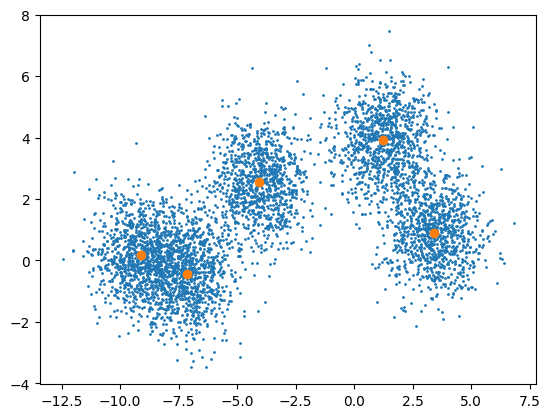

In [58]:
plt.figure()
plt.scatter(X[:,0], X[:,1], s=1)
plt.scatter(means_np[:,0], means_np[:,1])
plt.show()

In [59]:
def Distance(X, means,*args,**kwargs):
  diff=[]
  dists=[]
  for mean in means:
    diff=X-mean
    dist=np.sqrt(np.sum(diff**2,axis=1, keepdims=True))
    dists.append(dist)
  return np.hstack(dists)

In [60]:
class K_Means:
  def __init__(self, k=3, distance_func=Distance, beta=None):
    self.k=k
    self.distance_func=distance_func
    self.beta=beta

  def fit(self, X, iterations = 5):
    indices =np.arange(X.shape[0])
    sample_indices = np.random.choice(indices, size=self.k, replace=False)
    self.means =X[sample_indices]

    for i in range(iterations):
      plt.subplot(iterations//4 + 1, 4, i+1)
      y_hat = self.predict(X)
      self.means=[]
      for j in range(self.k):
        mean =np.mean(X[y_hat==j], axis=0)
        self.means.append(mean)
      self.means =np.vstack(self.means)

      # plt.figure()
      plt.scatter(X[:,0],X[:,1], s=1, c=y_hat)
      plt.scatter(self.means[:,0],self.means[:,1], c='k', s=9)
    plt.show()

    y_hat = self.predict(X)
    plt.figure()
    plt.scatter(X[:,0],X[:,1], s=1, c=y_hat)
    plt.scatter(self.means[:,0],self.means[:,1], c='k', s=9)
    plt.show()
    return y_hat

  def predict(self, X):
    dist = self.distance_func(X, self.means, self.beta)
    y_hat = np.argmin(dist, axis=1)
    return y_hat



In [61]:
kmeans_dist = K_Means(k=5)

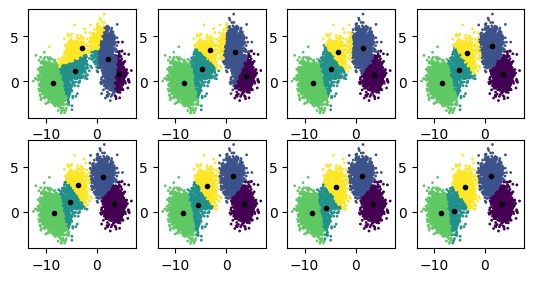

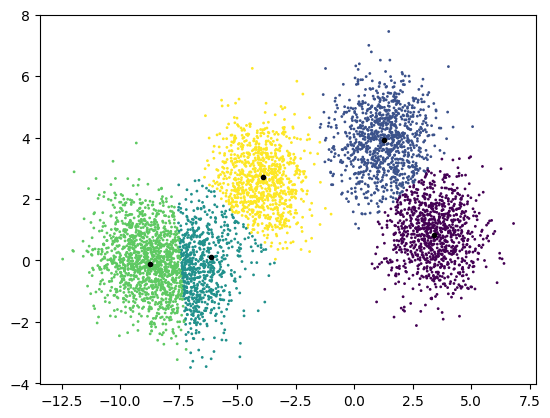

In [62]:
y_hat = kmeans_dist.fit(X, iterations=8)

# Unsupervised NLP Topic Modeling using Embeddings

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpy.linalg as lg
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras

In [64]:
embedding_model_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model_guse = hub.load(embedding_model_url)

In [65]:
def text_embed_guse_512(input_text):
  sentence_in = [input_text]
  return model_guse(sentence_in)

## Load Data to be Clustered


In [66]:
file_path = '/content/data_elonmusk2.csv'

In [67]:
pd.read_csv(file_path, encoding='iso-8859-1').tail()

,row ID,Tweet,Time,Retweet from,User
3213,Row3213,"@YOUSRC Amos's article was fair, but his edito...",11/20/2012 8:52,NaN,elonmusk
3214,Row3214,These articles in Space News describe why Aria...,11/20/2012 8:38,NaN,elonmusk
3215,Row3215,Was misquoted by BBC as saying Europe's rocket...,11/20/2012 8:30,NaN,elonmusk
3216,Row3216,Just returned from a trip to London and Oxford...,11/19/2012 8:59,NaN,elonmusk
3217,Row3217,RT @Jon_Favreau: My Model S just arrived and I...,11/16/2012 17:59,Jon_Favreau,elonmusk


In [68]:
def data_load(file_path):
  data = pd.read_csv(file_path, encoding='iso-8859-1')
  X = data.Tweet
  return X

In [69]:
def generate_ids(number, size):
  import string, random
  ids=[]
  for i in range(number):
    res = ''.join(random.choices(string.ascii_letters, k=size))
    ids.append(res)
    if len(set(ids)) != i+1:
      i-=1
      ids.pop(-1)

  return ids


In [73]:
def populate_Index(X, embed_func=text_embed_guse_512):
  dict_of_sentences = {}
  N = len(X)
  ids = generate_ids(N, 7)
  for i in range(N):
    # print(X[i])
    dict_of_sentences[i] = {"unique_id":ids[i], "Vector":embed_func(X[i]).numpy(), "Metadata":{"text":X[i]}}
  return dict_of_sentences

In [74]:
X = data_load(file_path)

In [75]:
tweet_index = populate_Index(X)

In [76]:
tweet_index[23]

{'unique_id': 'MqBCUzU',
 'Vector': array([[-5.41965291e-02, -6.40161037e-02,  4.56826948e-03,
         -2.43067406e-02,  2.43720040e-02, -5.60916327e-02,
         -2.53111105e-02, -1.68745890e-02, -8.01746920e-02,
         -9.05051157e-02, -3.25682499e-02,  1.32230558e-02,
          3.19364853e-02, -8.95939767e-02,  1.97230317e-02,
          1.06919827e-02,  1.16682397e-02, -8.03494651e-04,
          5.62556088e-02, -6.62942454e-02, -1.06742065e-02,
         -3.28763276e-02,  2.81777121e-02,  7.62109309e-02,
         -5.93735185e-03, -3.76911759e-02, -5.65260276e-02,
          2.74753422e-02, -5.13492636e-02,  2.59850174e-02,
          2.14633700e-02, -2.44961656e-03,  6.90590544e-03,
         -6.77865045e-03, -5.02794273e-02, -3.85192744e-02,
         -1.68059710e-02,  7.32877031e-02,  1.75549127e-02,
         -4.46230434e-02,  4.22467440e-02, -1.22216148e-02,
         -4.09687683e-02,  6.12836443e-02,  1.91107243e-02,
          1.29112359e-02,  2.37234328e-02,  4.72378805e-02,
     

## Clustering using K Means on Embeddings

In [77]:
def Train_data_from_Index(my_index_dict):
  return np.vstack([my_index_dict[i]['Vector'] for i in range(len(my_index_dict))])

In [78]:
X_tweets = Train_data_from_Index(tweet_index)

In [79]:
X_tweets.shape

(3218, 512)

In [80]:
def Distance(X, means,*args,**kwargs):
  diff=[]
  dists=[]
  for mean in means:
    diff=X-mean
    dist=np.sqrt(np.sum(diff**2,axis=1, keepdims=True))
    dists.append(dist)
  return np.hstack(dists)

In [85]:
def Responsibility(X,means,beta=1e-3,*args,**kwargs):
  diff=[]
  responsibilities=[]

  for mean in means:
    diff =X -mean
    dist =(np.sum(diff ** 2,axis=1,keepdims=True))

    numerator= np.exp(-(beta*dist))
    denominator=np.sum(numerator)
    responsibility=-numerator/denominator

    responsibilities.append(responsibility)
  return np.hstack(responsibilities)

In [81]:
def cluster_embeddings(X, distance_func=Distance, k=6, beta=0, iterations=20):
  kmeans =K_Means(k=k, distance_func=distance_func, beta=beta)
  y_hat=kmeans.fit(X, iterations=20)
  centroid_tweet_indices=[]
  print(y_hat)
  for cluster in range(k):
    centroid=kmeans.means[cluster]
    dists=np.sqrt(np.sum((centroid-X)**2,axis=1, keepdims=True))
    closest_index=np.argmin(dists)
    centroid_tweet_indices.append(closest_index)
  return centroid_tweet_indices,y_hat

In [82]:
def display_tweet_clusters(index_dict,name_index, obs_per_cluster,y_hat):
  k = len(set(y_hat))
  for j in range(k):
    count=0
    print("Representative Obs:"+index_dict[name_index[j]]["Metadata"]['text']+"\n")
    for i in range(len(index_dict)):
      if y_hat[i]==j:
        count+=1

        print("Cluster: "+str(y_hat[i])+" Tweet: "+index_dict[i]["Metadata"]['text'])
      if count>obs_per_cluster:break
    print('\n')


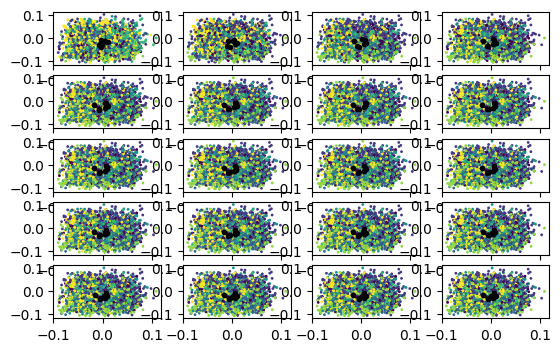

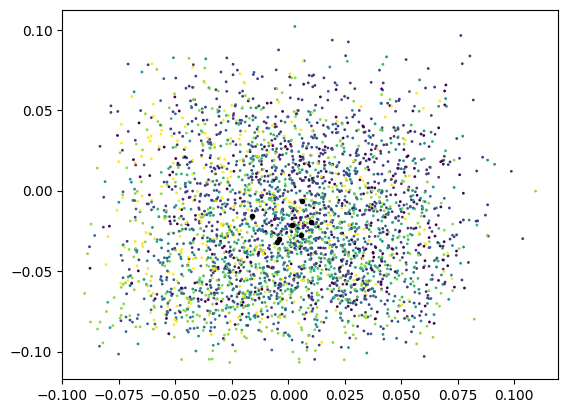

[6 4 1 ... 6 5 2]


In [90]:
name_index, clusters = cluster_embeddings(X_tweets, distance_func=Responsibility, k=7, beta=3)

In [91]:
display_tweet_clusters(tweet_index, name_index, 10, clusters)

Representative Obs:RT @YaelTAbouhalkah: Interesting: @nytimes public editor sides (mostly) with #Tesla. RT @Sulliview My thoughts on thorny problem: http:/ ...

Cluster: 0 Tweet: RT @mayemusk: .@covergirl I'm so excited to say that I'm now officially a COVERGIRL, at 69! Beauty is for all ages. #COVERGIRLMADE https://?
Cluster: 0 Tweet: RT @MotorTrend: Shocking winner of our latest, World's Greatest Drag Race 7! Maybe even #ludicrous? #WGDR7 https://t.co/ImvNAm2Yop
Cluster: 0 Tweet: RT @FastCompany: During Irma?s power outages, some houses kept the lights on with solar and batteries https://t.co/OHDMawHI0A https://t.co/?
Cluster: 0 Tweet: RT @Gizmodo: Hackers have already started to weaponize artificial intelligence https://t.co/x7WfEYJLOv https://t.co/gshNLUKSyi
Cluster: 0 Tweet: RT @TeslaMotors: Supercharging Cities https://t.co/IGK9FasWDa
Cluster: 0 Tweet: Hyperloop pod run by team WARR https://t.co/ntaMsoxkZE
Cluster: 0 Tweet: @berlinhedgehog @jmackin2 WSJ has been laboriously negat